In [1]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Loaded")

API Key Loaded


In [2]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

### **Create Schema**

In [3]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]

### **Create The Nodes**

In [4]:
def welcome(schema:graph_schema) -> graph_schema:
    
    curr_message = schema['messages']
    
    response = llm.invoke(curr_message).content
    
    schema['messages'] = f"You Message Was {curr_message}. Here's my response: {response}"
    
    return schema

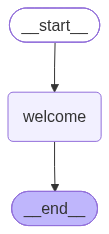

In [5]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("welcome",welcome)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

checkpoint = InMemorySaver() 

final_graph = graph.compile(checkpointer=checkpoint)
final_graph


In [10]:
response = final_graph.invoke(
    {"messages":"write a essay on ai"},
    {"configurable":{"thread_id":"rohit_lonkar"}}
)

for r in response['messages']:
    r.pretty_print()

================================ Human Message =================================

Hi My Name Is Rohit
================================ Human Message =================================

You Message Was [HumanMessage(content='Hi My Name Is Rohit', additional_kwargs={}, response_metadata={}, id='55e8cee7-9bdc-467a-9503-a76d7c33ddda')]. Here's my response: Hello Rohit! 👋 Nice to meet you. How can I assist you today?
================================ Human Message =================================

Hi My Name Is Rohit
================================ Human Message =================================

You Message Was [HumanMessage(content='Hi My Name Is Rohit', additional_kwargs={}, response_metadata={}, id='55e8cee7-9bdc-467a-9503-a76d7c33ddda'), HumanMessage(content="You Message Was [HumanMessage(content='Hi My Name Is Rohit', additional_kwargs={}, response_metadata={}, id='55e8cee7-9bdc-467a-9503-a76d7c33ddda')]. Here's my response: Hello Rohit! 👋 Nice to meet you. How can I assist you today?